# Q3 — Quais padrões podem ser identificados entre os municípios?

## Objetivo

Avaliar se o algoritmo **K-Means** consegue identificar grupos suficientemente coesos e separados entre os municípios brasileiros em 2025, considerando características socioeconômicas, territoriais e educacionais.

Nesta versão adotamos uma postura metodológica conservadora:

> **não escolher um número de clusters quando as evidências não sustentarem essa decisão.**

A unidade de análise é o **município**.

A variável `taxa_realizada` participa da clusterização juntamente com as demais features.

Fluxo:

> municípios de 2025 → features → imputação → padronização → K-Means para `K=2…8` → Inertia → Silhouette → tamanhos dos clusters → decisão metodológica.

Se os critérios não apontarem uma solução clara e defensável, a análise será encerrada sem forçar uma clusterização final.


## 1. Ambiente e leitura da base


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

ARQUIVO_DADOS = Path(
    '/content/drive/MyDrive/notebooks/dados_modelagem_municipio_ano_2024_2025.parquet'
)

if not ARQUIVO_DADOS.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado: {ARQUIVO_DADOS}'
    )

dados = pd.read_parquet(ARQUIVO_DADOS)

dados_2025 = dados.loc[
    dados['ano'].eq(2025)
].copy()

print(f'Linhas em 2025: {len(dados_2025):,}')
print(
    f'Municípios únicos: '
    f'{dados_2025["id_municipio"].nunique():,}'
)


Mounted at /content/drive
Linhas em 2025: 5,556
Municípios únicos: 5,556


## 2. Auditoria mínima da unidade de análise

Cada município deve aparecer uma única vez.

Identificadores como `id_municipio`, `nome_municipio` e `id_uf` não são utilizados como features do K-Means.


In [ ]:
duplicados = (
    dados_2025['id_municipio']
    .duplicated()
    .sum()
)

print(f'Municípios duplicados: {duplicados}')

if duplicados > 0:
    raise ValueError(
        'Existem municípios duplicados na base de 2025.'
    )


Municípios duplicados: 0


## 3. Features utilizadas

Utilizamos 11 variáveis.

A `taxa_realizada` está incluída porque queremos verificar se o conjunto completo de características — incluindo o resultado de alfabetização — forma agrupamentos naturais suficientemente claros.

Não existe variável-alvo: esta continua sendo uma análise de **Machine Learning não supervisionado**.


In [ ]:
FEATURES_CLUSTER = [
    'ctx_ibge_renda_domiciliar_per_capita_media',
    'ctx_atlas_indice_gini',
    'ctx_atlas_idhm_longevidade',
    'ctx_ibge_pct_populacao_rural',
    'ctx_ibge_pct_esgoto_adequado',
    'populacao',
    'ctx_atu_educacao_infantil',
    'ctx_atu_fundamental_anos_iniciais',
    'pct_rede_municipal',
    'ctx_atlas_taxa_fora_escola_6a14',
    'taxa_realizada',
]

faltantes = [
    col
    for col in FEATURES_CLUSTER
    if col not in dados_2025.columns
]

if faltantes:
    raise KeyError(
        f'Features ausentes: {faltantes}'
    )

X = dados_2025[FEATURES_CLUSTER].copy()

print(
    f'Matriz de modelagem: '
    f'{X.shape[0]:,} municípios × '
    f'{X.shape[1]} features'
)

display(
    X.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('n_ausentes')
)


Matriz de modelagem: 5,556 municípios × 11 features


,n_ausentes
ctx_atu_educacao_infantil,48
ctx_atlas_idhm_longevidade,6
ctx_atlas_indice_gini,6
ctx_atlas_taxa_fora_escola_6a14,6
ctx_ibge_renda_domiciliar_per_capita_media,1
ctx_ibge_pct_esgoto_adequado,1
ctx_ibge_pct_populacao_rural,1
populacao,0
ctx_atu_fundamental_anos_iniciais,0
pct_rede_municipal,0


## 4. Imputação e padronização

Os valores ausentes são imputados pela mediana.

Depois aplicamos `StandardScaler`, pois o K-Means utiliza distâncias e as variáveis possuem escalas diferentes.


In [ ]:
imputer = SimpleImputer(strategy='median')
X_imputado = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputado)

print(
    'Valores imputados:',
    int(X.isna().sum().sum())
)
print('Shape final:', X_scaled.shape)


Valores imputados: 69
Shape final: (5556, 11)


## 5. Avaliação de `K = 2` a `K = 8`

Não fixaremos previamente um número de clusters.

Para cada `K`, calculamos:

- Inertia;
- Silhouette Score;
- tamanho do menor e do maior cluster;
- percentual do menor e do maior cluster;
- percentual de municípios com Silhouette negativo.

A decisão só seria aceitável se os critérios apresentassem evidência convergente.


In [ ]:
resultados = []
labels_por_k = {}
silhuetas_por_k = {}

for k in range(2, 9):
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )

    labels = modelo.fit_predict(X_scaled)

    silhuetas = silhouette_samples(
        X_scaled,
        labels,
    )

    contagens = (
        pd.Series(labels)
        .value_counts()
    )

    resultados.append({
        'K': k,
        'inertia': modelo.inertia_,
        'silhouette': silhouette_score(
            X_scaled,
            labels,
        ),
        'menor_cluster_n': int(contagens.min()),
        'menor_cluster_pct': float(
            contagens.min() / len(labels) * 100
        ),
        'maior_cluster_n': int(contagens.max()),
        'maior_cluster_pct': float(
            contagens.max() / len(labels) * 100
        ),
        'pct_silhouette_negativo': float(
            (silhuetas < 0).mean() * 100
        ),
    })

    labels_por_k[k] = labels
    silhuetas_por_k[k] = silhuetas

avaliacao = pd.DataFrame(resultados)

display(avaliacao.round(4))


,K,inertia,silhouette,menor_cluster_n,menor_cluster_pct,maior_cluster_n,maior_cluster_pct,pct_silhouette_negativo
0,2,"49,480.7453",0.2007,2541,45.7343,3015,54.2657,2.9158
1,3,"44,194.7773",0.1817,1446,26.0259,2203,39.6508,3.7797
2,4,"40,910.7829",0.1756,414,7.4514,2089,37.5990,2.9338
3,5,"37,270.1736",0.1767,2,0.0360,2092,37.6530,3.8877
4,6,"34,839.7750",0.1510,2,0.0360,1456,26.2059,12.1670
5,7,"32,399.5874",0.1604,2,0.0360,1395,25.1080,7.9734
6,8,"30,863.7756",0.1473,2,0.0360,1337,24.0641,9.9712


## 6. Curva do cotovelo — Inertia

O método do cotovelo procura uma mudança de inclinação suficientemente clara na redução da Inertia.

Se a curva cair de forma gradual, sem uma inflexão evidente, o critério não fornece um número de clusters bem definido.


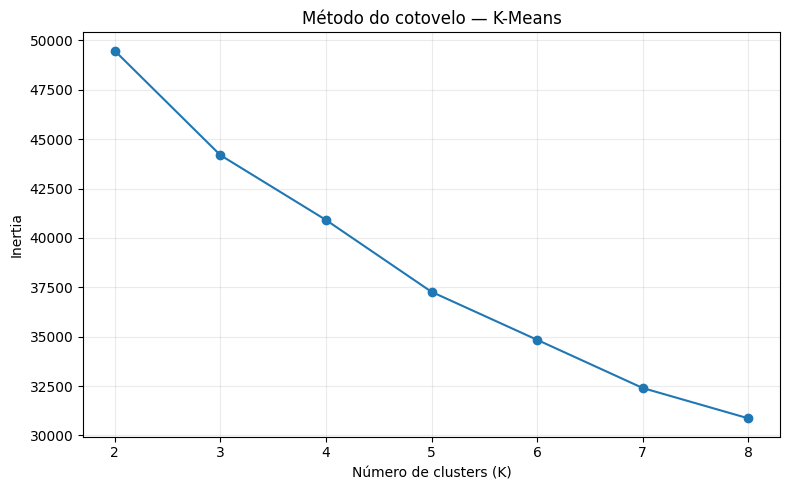

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    avaliacao['K'],
    avaliacao['inertia'],
    marker='o',
)

plt.title('Método do cotovelo — K-Means')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 9))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 7. Silhouette Score

O Silhouette combina coesão interna e separação entre os clusters.

Se os valores forem baixos e próximos entre si, não existe evidência forte para escolher um número ótimo de clusters.


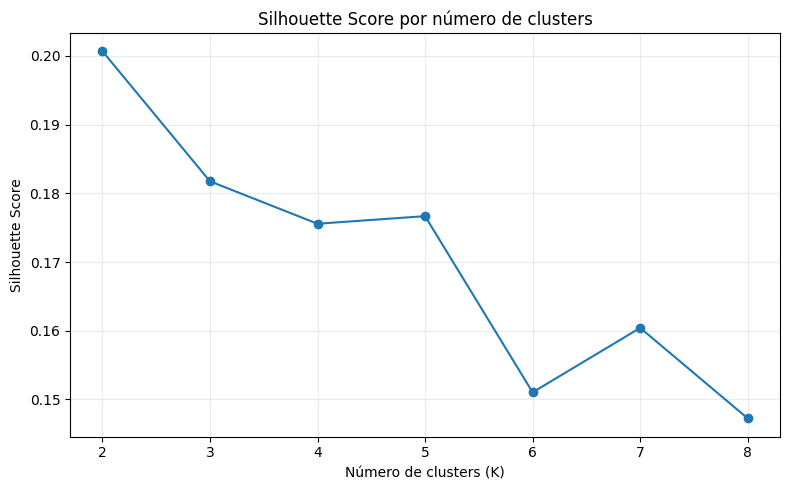

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    avaliacao['K'],
    avaliacao['silhouette'],
    marker='o',
)

plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 9))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Conclusão da Q3

Os resultados do K-Means **não forneceram evidência suficientemente clara para definir um número ótimo de clusters**.

A análise apresentou três sinais principais:

1. **Método do cotovelo:** a Inertia diminui conforme `K` aumenta, como esperado, mas não há uma inflexão suficientemente clara que justifique um valor específico de `K`.

2. **Silhouette:** os valores permanecem relativamente baixos e próximos entre diferentes valores de `K`. Não existe uma solução que se destaque de forma convincente em termos de coesão e separação.

3. **Estrutura dos clusters:** conforme aumentamos `K`, surgem grupos menores e maior fragmentação, sem ganho suficientemente claro nas métricas de separação.

As curvas de Silhouette também evidenciam municípios próximos às fronteiras entre clusters e, em alguns casos, coeficientes negativos, reforçando a existência de sobreposição entre os grupos.

## Resposta à pergunta

> **Com as variáveis analisadas e utilizando K-Means, não foi possível identificar uma estrutura de agrupamento robusta e claramente separada entre os municípios brasileiros em 2025.**

Consequentemente, também **não é metodologicamente adequado utilizar esses clusters para afirmar que determinadas regiões possuem padrões semelhantes**, pois essa conclusão dependeria de uma segmentação municipal que não apresentou evidência suficiente de validade interna.

Isso não significa que os municípios sejam idênticos ou que não existam diferenças regionais. Significa apenas que:

> **as evidências obtidas nesta análise não sustentam a existência de grupos naturais suficientemente bem definidos para serem representados por uma solução de K-Means.**

Por esse motivo, a análise é encerrada neste ponto, sem selecionar artificialmente um valor de `K` e sem produzir uma caracterização regional baseada em clusters pouco sustentados.

## Limitação

Esta conclusão é específica para:

- as features selecionadas;
- os dados de 2025;
- a padronização utilizada;
- a distância euclidiana;
- o algoritmo K-Means.

Outras técnicas ou outras representações dos dados poderiam produzir estruturas diferentes, mas não são necessárias para responder esta etapa de forma conservadora.
